# Dataset Splitting Paradigm

The goal here would be to split a dataset into train, dev and test subset such that all 3 classes have overlapping terms but also terms unique to each of the classes, in order to mimic an accurate and complete learning process.

In [143]:
import pandas as pd
import datasets
import matplotlib.pyplot as plt
import numpy as np

## Dataset Analysis

In [144]:
df = pd.read_json('data/complete_data.jsonl', lines=True)
df.head()

,input,output,page_number,file_name
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,,8,Divan_Prak10
1,խմբագրական խորհուրդ՝ գր ս գրիգորյան հ ա մելքոն...,,8,Divan_Prak10
2,պրակը հրատարակության պատրաստեցին՝ պատմ գիտ թեկ...,,8,Divan_Prak10
3,պատասխանատու խմբագիրներ՝ գ գ սարգսյան ա է հարո...,,8,Divan_Prak10
4,դ դիվան հայ վիմագրության պրակ շիրակի մարզ կազմ...,,8,Divan_Prak10


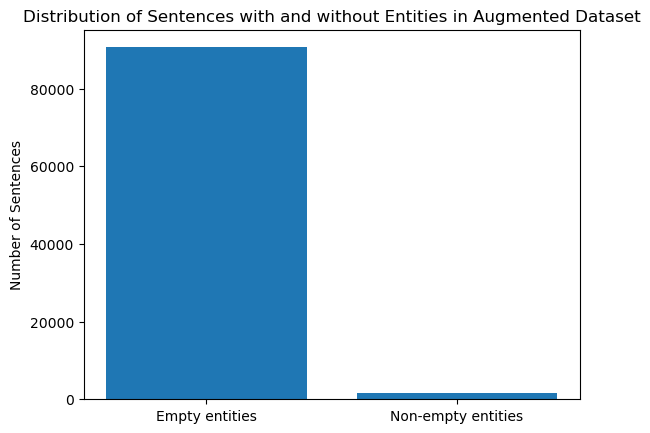

In [145]:
df_balance = df.copy()
df_balance['output'] = df_balance['output'].replace('', pd.NA)

plt.bar(
    x=['Empty entities', 'Non-empty entities'],
    height=[
        df_balance['output'].isna().sum(),
        (~df_balance['output'].isna()).sum()
    ]
)
plt.ylabel('Number of Sentences')
plt.title('Distribution of Sentences with and without Entities in Augmented Dataset')
plt.show()

## IOB Formatting

In [146]:
df['output'] = df['output'].apply(lambda x: x.split(':')[0] if ':' in str(x) else None)
df.rename(columns={'input':'sentence','output':'term'},inplace=True)
df['word'] = df['sentence'].apply(lambda x: str(x).split())    
df_exploded = df.explode('word')
df_exploded

,sentence,term,page_number,file_name,word
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,տպագրվում
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,է
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,հ
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,գաս
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,հնագիտության
...,...,...,...,...,...
92199,սփյուռքում պահպանված պատմական հուշարձանների հա...,None,674,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,պահպանված
92199,սփյուռքում պահպանված պատմական հուշարձանների հա...,None,674,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,պատմական
92199,սփյուռքում պահպանված պատմական հուշարձանների հա...,None,674,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,հուշարձանների
92199,սփյուռքում պահպանված պատմական հուշարձանների հա...,None,674,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,համակողմանի


In [147]:
def tag_logic(reference_terms, word):
    if not reference_terms or pd.isna(reference_terms):
        return 'O'
    
    ref_terms = reference_terms.lower().split()
    word_lower = word.lower()
    
    for i, ref in enumerate(ref_terms):
        # Match exact word, word starting with ref, or word containing ref
        if word_lower == ref or word_lower.startswith(ref) or ref in word_lower:
            return 'B-INSC' if i == 0 else 'I-INSC'
    
    return 'O'


In [148]:
df_exploded['tag'] = df_exploded.apply(lambda x: tag_logic(x['term'], x['word']), axis=1)
df_exploded

,sentence,term,page_number,file_name,word,tag
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,տպագրվում,O
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,է,O
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,հ,O
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,գաս,O
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,հնագիտության,O
...,...,...,...,...,...,...
92199,սփյուռքում պահպանված պատմական հուշարձանների հա...,None,674,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,պահպանված,O
92199,սփյուռքում պահպանված պատմական հուշարձանների հա...,None,674,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,պատմական,O
92199,սփյուռքում պահպանված պատմական հուշարձանների հա...,None,674,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,հուշարձանների,O
92199,սփյուռքում պահպանված պատմական հուշարձանների հա...,None,674,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,համակողմանի,O


In [149]:
df_exploded['word_labels'] = df_exploded[['sentence','tag']].groupby('sentence').transform(lambda x: ','.join(x))
df_exploded

,sentence,term,page_number,file_name,word,tag,word_labels
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,տպագրվում,O,"O,O,O,O,O,O,O,O,O,O,O"
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,է,O,"O,O,O,O,O,O,O,O,O,O,O"
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,հ,O,"O,O,O,O,O,O,O,O,O,O,O"
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,գաս,O,"O,O,O,O,O,O,O,O,O,O,O"
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,None,8,Divan_Prak10,հնագիտության,O,"O,O,O,O,O,O,O,O,O,O,O"
...,...,...,...,...,...,...,...
92199,սփյուռքում պահպանված պատմական հուշարձանների հա...,None,674,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,պահպանված,O,"O,O,O,O,O,O"
92199,սփյուռքում պահպանված պատմական հուշարձանների հա...,None,674,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,պատմական,O,"O,O,O,O,O,O"
92199,սփյուռքում պահպանված պատմական հուշարձանների հա...,None,674,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,հուշարձանների,O,"O,O,O,O,O,O"
92199,սփյուռքում պահպանված պատմական հուշարձանների հա...,None,674,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,համակողմանի,O,"O,O,O,O,O,O"


In [150]:
df_exploded.drop_duplicates(subset=['sentence'], inplace=True)

In [151]:
df_exploded=df_exploded[df_exploded['file_name']!='Divan_Prak10']

In [152]:
df_exploded

,sentence,term,page_number,file_name,word,tag,word_labels
2747,հայկական սսռ գիտությունների ակադեմիայի պատմութ...,Վիմագիր,6,Divan_Prak2,հայկական,O,"O,O,O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O"
2748,քանի որ այգ աշխատանքը կապված է տևական ժամանակի...,None,6,Divan_Prak2,քանի,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
2749,հինգ տարի է արդեն որ այդ հպատակով ամառվա երկու...,None,6,Divan_Prak2,հինգ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O"
2750,հավաքման աշխատանքեերի սյունիքից սկսելը բացի տե...,None,6,Divan_Prak2,հավաքման,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O"
2751,ներկա պրակի մեջ ամփոփված են երեք շրջանների արձ...,None,6,Divan_Prak2,ներկա,O,"O,O,O,O,O,O,O,O,O,O,O,O"
...,...,...,...,...,...,...,...
92192,վրհտ ի,None,654,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,վրհտ,O,"O,O"
92194,օշական,None,654,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,օշական,O,O
92195,բ հայկական ճարտարապետությունն ուսումնասիրող հի...,None,674,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,բ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O"
92198,նպատակն է իրականացնել ներկայիս հայաստանի հանրա...,None,674,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,նպատակն,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O"


## EDA

In [153]:
# Count total and unique terms
total_terms = len(df_exploded['term'])
unique_terms = df_exploded['term'].nunique()

# Nicely formatted output
print(f"Total number of terms: {total_terms:,}")
print(f"Number of unique terms: {unique_terms:,}")
print(f"Ratio of unique terms: {unique_terms / total_terms:.2%}")

Total number of terms: 67,754
Number of unique terms: 137
Ratio of unique terms: 0.20%


In [154]:
print("Top 10 most frequent terms:")
print(df_exploded['term'].value_counts().head(10))

Top 10 most frequent terms:
term
վիմագրերը                       48
Վիմագիր                         41
Շինարարական արձանագրություն     30
վիմագրերում                     26
վիմագրեր                        22
տապանաքար                       21
վիմագիրը                        20
տապանագիրը                      20
վիմագիր                         19
շինարարական արձանագրությունը    17
Name: count, dtype: int64


* epitaphs 53
* epitaph 51
* Construction Inscription 31
* epitaph 30
* epitaphs 28
* epitaph 24
* epitaph 22
* tombstone 21
* epitaph 20
* epitaph Inscription 18

In [155]:
df_exploded['term'].unique()

array(['Վիմագիր', None, 'Տապանագիր', 'փակագիր արձանագրություն',
       'Շինարարական արձանագրություն', 'վիմական արձանադրությունների',
       'տապանաքարային արձանագրություն', 'Գերեզմանատան արձանագրություն',
       'շինարարական արձանագրությունների', 'շինարարական արձանագրութլուն',
       'նվիրատվական արձանագրության', 'նվիրատվական արձանագրություն',
       'շինարարական մեծ արձանագրության', 'տապանագիր',
       'շինարարական արձանագրության', 'հիշատակագիր',
       'նորոգման արձանագրություն', 'վիմական արձանագրությունների',
       'եկեղեցու արձանագրության', 'եկեղեցու ... արձանագրության',
       'տապանագրի', 'տապանազրի', 'տապանագրերի', 'տապանագրերից',
       'տապանագիրը', 'տապանագրերը', 'տապանագրեր', 'շինարարական',
       'Վերանորոգման', 'վանքի արձանագրության', 'վիմական արձանագրություն',
       'փակագիր', 'բարավորի', 'փակագիրը', 'բարավոր', 'տապանագրերն',
       'շինարարական արձանագրությունները', 'տապանագրությունները',
       'նվիրագիր', 'վիմագիր', 'վիմագրեր', 'վիմագրության', 'տապանագրով',
       'ն

```* վիմական արձանագրությունները — rock inscriptions
* վիմագիր — inscription
* վիմագրերը — inscriptions
* վիմական արձանագրություն — rock inscription
* Վիմագիր — Inscription
* վիմագիրը — the inscription
* վիմագրերի — of inscriptions
* վիմագրերում — in inscriptions
* վիմագրի — of the inscription
* վիմագրերով — with inscriptions
* վիմագրությունը — inscription (the act or state)
* տապանագրի — of the tombstone inscription
* վիմագրահավաքը — collection of inscriptions
* Շինարարական արձանագրություն — construction inscription
* վիմագրում — in the inscription
* նվիրագիր — dedication
* Տապանագիր — epitaph / tomb inscription
* վիմագրեր — inscriptions
* տապանագրերը — tombstone inscriptions
* տապանագիրը — the tomb inscription
* վիմագիրն — the inscription
* տապանագրից — from the tomb inscription
* տապանագիր — tomb inscription
* փակագիր արձանագրություն — sealed inscription / closed inscription
* խաչքար — khachkar (Armenian cross-stone)
* վիմական արձանադրությունների — of rock inscriptions
* տապանաքարային արձանագրություն — tombstone inscription
* Գերեզմանատան արձանագրություն — cemetery inscription
* շինարարական արձանագրությունների — of construction inscriptions
* շինարարական արձանագրութլուն — construction inscription (variant spelling)
* նվիրատվական արձանագրության — of donation inscription
* նվիրատվական արձանագրություն — donation inscription
* շինարարական մեծ արձանագրության — of a large construction inscription
* շինարարական արձանագրության — of the construction inscription
* հիշատակագիր — commemorative note / memorandum
* նորոգման արձանագրություն — renovation inscription
* վիմական արձանագրությունների — of rock inscriptions
* եկեղեցու արձանագրության — of church inscription
* եկեղեցու ... արձանագրության — of the church’s ... inscription
* տապանազրի — (variant of epitaph)
* տապանագրերի — of tomb inscriptions
* տապանագրերից — from tomb inscriptions
* տապանագրեր — tomb inscriptions
* շինարարական — constructional
* Վերանորոգման — of renovation
* վանքի արձանագրության — of monastery inscription
* փակագիր — sealed text / script
* բարավորի — of lintel (architectural term)
* փակագիրը — the sealed inscription
* բարավոր — lintel inscription
* տապանագրերն — the tomb inscriptions
* շինարարական արձանագրությունները — the construction inscriptions
* տապանագրությունները — the tomb inscriptions
* վիմագրության — of epigraphy / inscription
* տապանագրով — with a tomb inscription
* նվիրագիրը — the dedication
* վերանորոգման — of renovation
* շինարարական արձանաղրության — of construction inscription (variant)
* նվիրագրի — of dedication
* շինարարական արձանագրությունը — the construction inscription
* նըվիրագիրը — (variant) the dedication
* վերանորոգմանը — to the renovation
* վիմագրերից — from inscriptions
* տապանագրությունը — the tomb inscription
* վիմական արձանագրություններում — in rock inscriptions
* շինարարական արձանագրութլյունը — the construction inscription (variant spelling)
* որմնագիր — wall inscription
* վիմագրությունները — the inscriptions
* վիմագրություններ — inscriptions
* վիմագրված — inscribed
* վիմադրությունները — (variant of inscriptions)
* վիմաղրերի — of inscriptions (archaic/variant form)
* փակագրով — with a sealed text
* վիմագիրս — my inscription
* փակաղիր — (possibly variant of “sealed script”)
* վիմադրեր — inscribed stones
* Բարավորի արձանագրություն — lintel inscription
* շինարարական արձանադրության — of construction inscription (variant spelling)
* վիմագրական — epigraphic
* վիմագրությամբ — with inscription
* վիմագրական արշավախմբի — of an epigraphic expedition
* տապանաքար — tombstone
* տապանաքարեր — tombstones
* կոթողի — of a monument
* տապանաքարայս — this tombstone
* տապանագիրն — the epitaph
* վիմագրագիտական — epigraphical / epigraphy-related
* վեր նորոգման — of renovation (split spelling)
* ատպանագրերը — (variant of tomb inscriptions)
* ատպանադըրերը — (garbled variant of tomb inscriptions)
* տապանագրևըի — (misspelling of “of the tomb inscription”)
* վիմաղրերում — in inscriptions (variant)
* ատպանադրերից — from tomb inscriptions (variant)
* ժամատան թ արձանագրության — of the chapel’s inscription
* հիշատակագիրը — the commemorative note
* զանգակատան արձանագրությունում — in the bell tower’s inscription
* նվիրատվական արձանագրություններում — in donation inscriptions
* խաչքարի արձանագրության — of the khachkar’s inscription
* շինարարական արձանագրությունում — in the construction inscription
* տապանագրում — in the tomb inscription
* խաչքարերի ... արձանագրության — of the khachkars’ ... inscription
* ժամատան ... արձանագրության — of the chapel’s ... inscription
* վիմական արձանագրություններ — rock inscriptions
* բարավորի արձանագրությունեերը — the lintel inscriptions (variant)
* վիմագրերուճ — (misspelling of inscriptions)
* նվիրագրին — to the dedication
* շինարարական արձանագրությամբ — with construction inscription
* շինարարական արձանացգրություն — (variant spelling of construction inscription)
* նվիրատվական արձանագրություններ — donation inscriptions
* հիշատակագիրն — the commemorative note
* հիշատակագրություններ — commemorative notes
* վիմական արձանագրություններով — with rock inscriptions
* շինարարական արձանագրություն — construction inscription
* նորոգման արձանագրությունը — the renovation inscription
* տապանագրին — to the tomb inscription
* վիմագրին — to the inscription
* շինարարական արձանագրություը — (variant spelling of construction inscription)
* վիմագրեիը — (variant spelling of inscription)
* շինարարական արձանարությունը — (variant spelling of construction inscription)
* շինարարական արձանագրություններ — construction inscriptions
* հուշագրով — with a memorandum
* հուշագիրը — the memorandum
* շինարարական արձանագրության մեջ — inside the construction inscription
* ժամատան հարավային մուտքի կամարի արձանագրությունը — the inscription on the southern entrance arch of the chapel
* Նվիրատվական արձանագրություն — Donation inscription
* գերեզմանատան արձանագրությունների — of the cemetery inscriptions
* Հուշագիր — Memorandum
* շինարարական ... արձանագրությամբ — with construction ... inscription
* տապանաքարերի արձանագրությունները — the inscriptions of tombstones
* եկեղեցու արձ — church insc... (truncated)
* գերեզմանատան արձ — cemetery insc... (truncated)
* նվիրատվական արձանագրությունը — the donation inscription
* խաչքար տեղահան արձանագրությունը — inscription of relocated khachkar
* Եկեղեցու արձանագրություն — Church inscription
* նորոգման արձանագրության — of the renovation inscription
* եկեղեցու արձանագրությունները — the church inscriptions
* գերեզմանատան արձանագրությունները — the cemetery inscriptions
* խաչքար արձանագրությունը — the khachkar inscription
* Կանոնագիր — Canon / Rulebook
* կանոնագիր — canon / rulebook
```

## Overlapping Split

In [25]:
import pandas as pd
import random
import seaborn as sns

def split_jsonl_dataset(df, train_frac=0.8, eval_frac=0.1, test_frac=0.1, random_state=42):
    """
    Splits a JSONL NER dataset into train/eval/test sets while holding out terms.
    """
    
    # 3 Split terms into train/eval/test
    all_terms = df['term'].dropna().unique().tolist()
    random.seed(random_state)
    random.shuffle(all_terms)
    
    n_terms = len(all_terms)
    n_train = int(train_frac * n_terms)
    n_eval  = int(eval_frac * n_terms)
    
    train_terms = all_terms[:n_train]
    eval_terms  = all_terms[n_train:n_train+n_eval]
    test_terms  = all_terms[n_train+n_eval:]
    
    # 4️ Assign samples based on term membership
    train_df = df[df['term'].isin(train_terms)].copy()
    eval_df  = df[df['term'].isin(eval_terms)].copy()
    test_df  = df[df['term'].isin(test_terms)].copy()
    
    # 5 Add remaining no-entity samples proportionally
    no_entity_df = df[df['term'].isna()]
    n_total = len(no_entity_df)
    n_train_noentity = int(train_frac * n_total)
    n_eval_noentity  = int(eval_frac * n_total)
    
    no_entity_df = no_entity_df.sample(frac=1, random_state=random_state)
    train_df = pd.concat([train_df, no_entity_df.iloc[:n_train_noentity]])
    eval_df  = pd.concat([eval_df,  no_entity_df.iloc[n_train_noentity:n_train_noentity+n_eval_noentity]])
    test_df  = pd.concat([test_df,  no_entity_df.iloc[n_train_noentity+n_eval_noentity:]])
    
    # 6️ Shuffle splits
    train_df = train_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    eval_df  = eval_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    test_df  = test_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    return train_df, eval_df, test_df


def plot_term_distribution(train_df, eval_df, test_df, top_n=20):
    """
    Plots the distribution of terms across train/eval/test splits.
    """
    # Add set labels
    train_df_plot = train_df[['term']].copy()
    train_df_plot['set'] = 'train'
    eval_df_plot  = eval_df[['term']].copy()
    eval_df_plot['set'] = 'eval'
    test_df_plot  = test_df[['term']].copy()
    test_df_plot['set'] = 'test'
    
    plot_df = pd.concat([train_df_plot, eval_df_plot, test_df_plot], ignore_index=True)
    concat_df = plot_df.copy()
    plot_df = plot_df.dropna(subset=['term'])
    
    # Keep top N terms by total count
    top_terms = plot_df['term'].value_counts().head(top_n).index
    plot_df = plot_df[plot_df['term'].isin(top_terms)]
    
    plt.figure(figsize=(12,6))
    sns.countplot(data=plot_df, x='term', hue='set')
    plt.xticks(rotation=90)
    plt.title(f"Distribution of Top {top_n} Terms Across Train/Eval/Test")
    plt.xlabel("Term")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    return concat_df


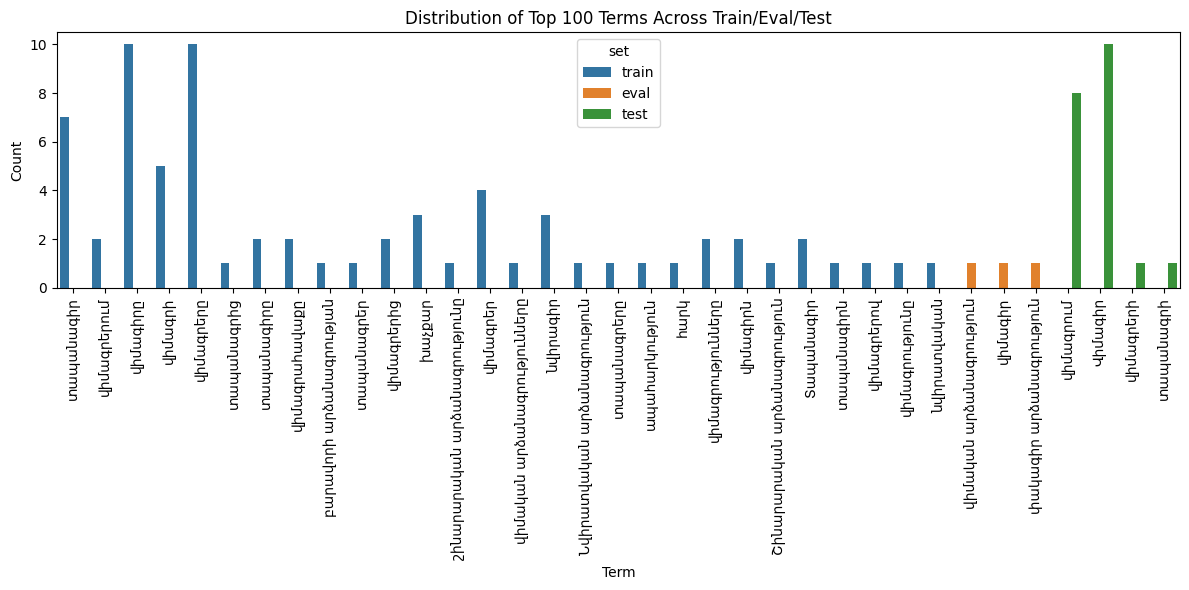

In [133]:
train_df, eval_df, test_df = split_jsonl_dataset(df_exploded)
dataset = plot_term_distribution(train_df, eval_df, test_df, top_n=100)

## Non-random Train Dev Test Split

In [156]:
df_exploded.term.unique()

array(['Վիմագիր', None, 'Տապանագիր', 'փակագիր արձանագրություն',
       'Շինարարական արձանագրություն', 'վիմական արձանադրությունների',
       'տապանաքարային արձանագրություն', 'Գերեզմանատան արձանագրություն',
       'շինարարական արձանագրությունների', 'շինարարական արձանագրութլուն',
       'նվիրատվական արձանագրության', 'նվիրատվական արձանագրություն',
       'շինարարական մեծ արձանագրության', 'տապանագիր',
       'շինարարական արձանագրության', 'հիշատակագիր',
       'նորոգման արձանագրություն', 'վիմական արձանագրությունների',
       'եկեղեցու արձանագրության', 'եկեղեցու ... արձանագրության',
       'տապանագրի', 'տապանազրի', 'տապանագրերի', 'տապանագրերից',
       'տապանագիրը', 'տապանագրերը', 'տապանագրեր', 'շինարարական',
       'Վերանորոգման', 'վանքի արձանագրության', 'վիմական արձանագրություն',
       'փակագիր', 'բարավորի', 'փակագիրը', 'բարավոր', 'տապանագրերն',
       'շինարարական արձանագրությունները', 'տապանագրությունները',
       'նվիրագիր', 'վիմագիր', 'վիմագրեր', 'վիմագրության', 'տապանագրով',
       'ն

In [157]:
testing_terms = ['խաչքար', 'հարկ', 'տապանագիր', 'Տապանագիր', 'նվիրատվական',
                 'շինարարական արձանագրությունը', 'Շինարարական արձանագրություն', 'ապահարկություն']

```
'khachkar', 'tax', 'coffin', 'coffin', 'donation',
'construction protocol', 'Construction protocol', 'reservation'
```

In [158]:
testing_positives = df_exploded[df_exploded['term'].isin(testing_terms)].reset_index(drop=True)
testing_positives.head()

,sentence,term,page_number,file_name,word,tag,word_labels
0,տաթեվ մ լուսավորչի հարավում աապանագիր,Տապանագիր,40,Divan_Prak2,տաթեվ,O,"O,O,O,O,O"
1,դլուղի անունով կոչվող վանքի վայրում ըստ նույն ...,Շինարարական արձանագրություն,100,Divan_Prak2,դլուղի,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
2,ալդ արձանագրություններից մեկը շինարարական է հր...,Շինարարական արձանագրություն,109,Divan_Prak3,ալդ,O,"O,I-INSC,O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
3,չհրատարակվածներից առանձնապես կարևոր է մի տապան...,տապանագիր,173,Divan_Prak3,չհրատարակվածներից,O,"O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O"
4,տրիմքինդ տանող ճանապարհի վրա աղբլուրների ակներ...,տապանագիր,95,Divan_Prak4,տրիմքինդ,O,"O,O,O,O,O,O,O,O,O,O,O,B-INSC,O,O"


In [159]:
training_positives = df_exploded[
    df_exploded['term'].notna() & ~df_exploded['term'].isin(testing_terms)
].reset_index(drop=True)

training_positives.head()

,sentence,term,page_number,file_name,word,tag,word_labels
0,հայկական սսռ գիտությունների ակադեմիայի պատմութ...,Վիմագիր,6,Divan_Prak2,հայկական,O,"O,O,O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O"
1,համար գործածված է մեկ անգամ հարավ արևելյան խոր...,փակագիր արձանագրություն,94,Divan_Prak2,համար,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O"
2,ցահկեր ցանկ վիմական արձանադրությունների մեջ գո...,վիմական արձանադրությունների,241,Divan_Prak2,ցահկեր,O,"O,O,B-INSC,I-INSC,O,O,O,O,O,O,O,O,O,O"
3,գլուղի կենարոնում կա նաև մի փոքրիկ թաղածածկ եկ...,տապանաքարային արձանագրություն,110,Divan_Prak3,գլուղի,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,I-INSC,O,O,O,O,O,O"
4,արևելյան եղրի գերեզմանատան մեջ՝ իրար կողքի որո...,Գերեզմանատան արձանագրություն,118,Divan_Prak3,արևելյան,O,"O,O,B-INSC,O,O,O,O,O,O,O,O,I-INSC,O,O,O,O,O,O,..."


In [160]:
training_positives.term.unique()

array(['Վիմագիր', 'փակագիր արձանագրություն',
       'վիմական արձանադրությունների', 'տապանաքարային արձանագրություն',
       'Գերեզմանատան արձանագրություն', 'շինարարական արձանագրությունների',
       'շինարարական արձանագրութլուն', 'նվիրատվական արձանագրության',
       'նվիրատվական արձանագրություն', 'շինարարական մեծ արձանագրության',
       'շինարարական արձանագրության', 'հիշատակագիր',
       'նորոգման արձանագրություն', 'վիմական արձանագրությունների',
       'եկեղեցու արձանագրության', 'եկեղեցու ... արձանագրության',
       'տապանագրի', 'տապանազրի', 'տապանագրերի', 'տապանագրերից',
       'տապանագիրը', 'տապանագրերը', 'տապանագրեր', 'շինարարական',
       'Վերանորոգման', 'վանքի արձանագրության', 'վիմական արձանագրություն',
       'փակագիր', 'բարավորի', 'փակագիրը', 'բարավոր', 'տապանագրերն',
       'շինարարական արձանագրությունները', 'տապանագրությունները',
       'նվիրագիր', 'վիմագիր', 'վիմագրեր', 'վիմագրության', 'տապանագրով',
       'նվիրագիրը', 'վերանորոգման', 'շինարարական արձանաղրության',
       'նվիրա

In [161]:
eval_terms = ['փակագիր արձանագրություն','վիմագրահավաքը','տապանագրերը','Նվիրատվական արձանագրություն',
              'տապանագիրն','վիմագիր','վիմագրերը']

eval_positives = training_positives[training_positives['term'].isin(eval_terms)].reset_index(drop=True)
training_positives = training_positives[~training_positives['term'].isin(eval_terms)].reset_index(drop=True)

In [162]:
eval_positives.head()

,sentence,term,page_number,file_name,word,tag,word_labels
0,համար գործածված է մեկ անգամ հարավ արևելյան խոր...,փակագիր արձանագրություն,94,Divan_Prak2,համար,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O"
1,թե եկեղեցին իր ձևերով և թե տապանագրերը վերաբեր...,տապանագրերը,119,Divan_Prak4,թե,O,"O,O,O,O,O,O,B-INSC,O,O,O"
2,զ հին գերեզմանատուն ուր կան հետևլալ տապանագրերը,տապանագրերը,145,Divan_Prak5,զ,O,"O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O"
3,ս հովհաննես եկեղեցու գավթի մեջ եղել են հետևյալ...,տապանագրերը,228,Divan_Prak5,ս,O,"O,O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O"
4,վանքի տմենահին կառույցը՝ ս գրիգոր եկեղեցին վիմ...,վիմագիր,22,Divan_Prak6,վանքի,O,"O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O,O..."


In [163]:
eval_positives.term.unique()

array(['փակագիր արձանագրություն', 'տապանագրերը', 'վիմագիր', 'վիմագրերը',
       'տապանագիրն', 'Նվիրատվական արձանագրություն'], dtype=object)

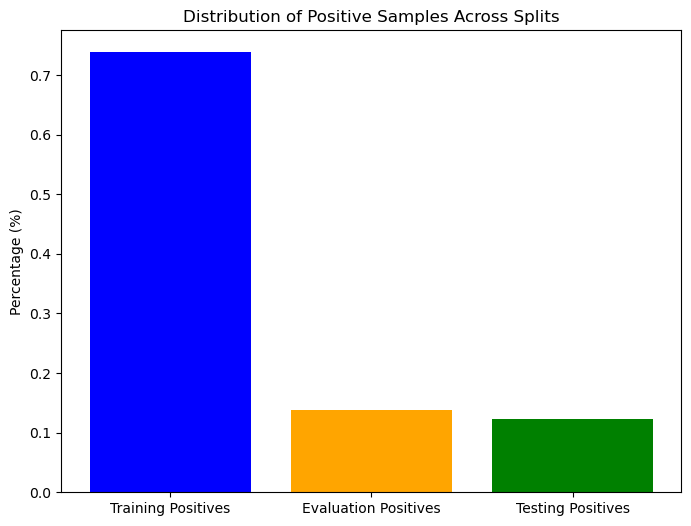

In [164]:
total_len = len(training_positives) + len(eval_positives) + len(testing_positives)

relative_len=[len(training_positives)/total_len, len(eval_positives)/total_len, len(testing_positives)/total_len]
labels = ['Training Positives', 'Evaluation Positives', 'Testing Positives']
plt.figure(figsize=(8,6))
plt.bar(labels, relative_len, color=['blue', 'orange', 'green'])
plt.ylabel('Percentage (%)')
plt.title('Distribution of Positive Samples Across Splits')
plt.show()

In [165]:
no_entity_df = df_exploded[df_exploded['term'].isna()]
n_total = len(no_entity_df)
n_train_noentity = int((len(training_positives)/total_len) * n_total)
n_eval_noentity  = int((len(eval_positives)/total_len) * n_total)

train_df_doctored = pd.concat([training_positives, no_entity_df.iloc[:n_train_noentity]])
eval_df_doctored  = pd.concat([eval_positives, no_entity_df.iloc[n_train_noentity:n_train_noentity+n_eval_noentity]])
test_df_doctored  = pd.concat([testing_positives, no_entity_df.iloc[n_train_noentity+n_eval_noentity:]])

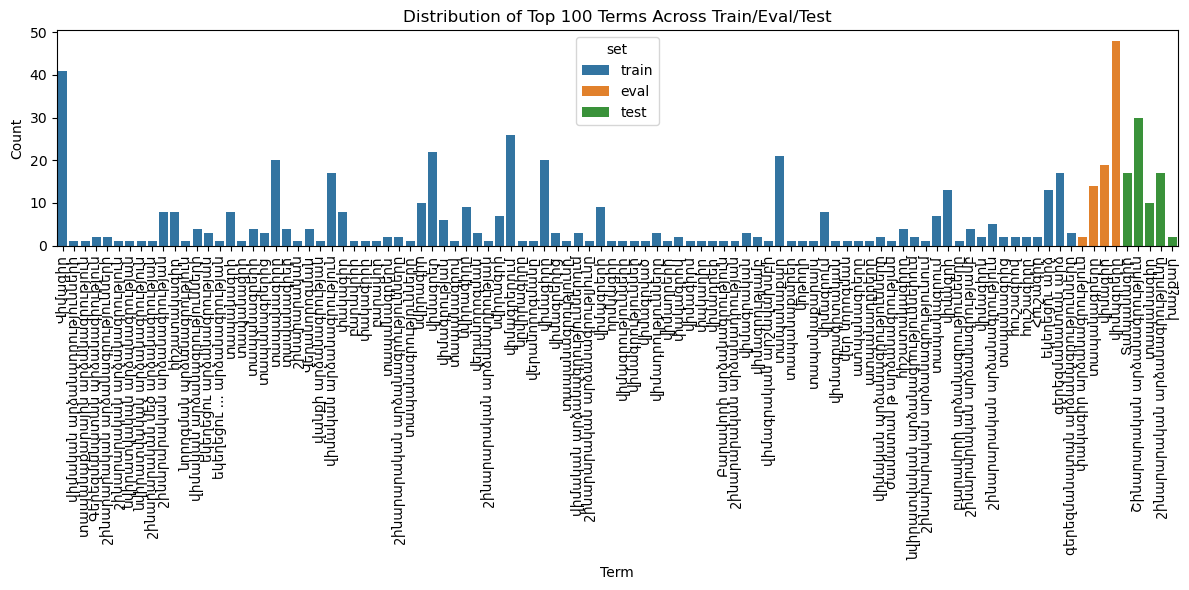

,term,set
0,Վիմագիր,train
1,վիմական արձանադրությունների,train
2,տապանաքարային արձանագրություն,train
3,Գերեզմանատան արձանագրություն,train
4,շինարարական արձանագրությունների,train
...,...,...
67749,None,test
67750,None,test
67751,None,test
67752,None,test


In [166]:
plot_term_distribution(train_df_doctored, eval_df_doctored, test_df_doctored, top_n=100)

In [167]:
train_df_doctored.term.unique()

array(['Վիմագիր', 'վիմական արձանադրությունների',
       'տապանաքարային արձանագրություն', 'Գերեզմանատան արձանագրություն',
       'շինարարական արձանագրությունների', 'շինարարական արձանագրութլուն',
       'նվիրատվական արձանագրության', 'նվիրատվական արձանագրություն',
       'շինարարական մեծ արձանագրության', 'շինարարական արձանագրության',
       'հիշատակագիր', 'նորոգման արձանագրություն',
       'վիմական արձանագրությունների', 'եկեղեցու արձանագրության',
       'եկեղեցու ... արձանագրության', 'տապանագրի', 'տապանազրի',
       'տապանագրերի', 'տապանագրերից', 'տապանագիրը', 'տապանագրեր',
       'շինարարական', 'Վերանորոգման', 'վանքի արձանագրության',
       'վիմական արձանագրություն', 'փակագիր', 'բարավորի', 'փակագիրը',
       'բարավոր', 'տապանագրերն', 'շինարարական արձանագրությունները',
       'տապանագրությունները', 'նվիրագիր', 'վիմագրեր', 'վիմագրության',
       'տապանագրով', 'նվիրագիրը', 'վերանորոգման',
       'շինարարական արձանաղրության', 'նվիրագրի', 'վիմագրերում',
       'նըվիրագիրը', 'վերանորոգմանը', '

In [168]:
eval_df_doctored.term.unique()

array(['փակագիր արձանագրություն', 'տապանագրերը', 'վիմագիր', 'վիմագրերը',
       'տապանագիրն', 'Նվիրատվական արձանագրություն', None], dtype=object)

In [169]:
test_df_doctored.term.unique()

array(['Տապանագիր', 'Շինարարական արձանագրություն', 'տապանագիր',
       'շինարարական արձանագրությունը', 'խաչքար', None], dtype=object)

In [170]:
train_old= pd.read_csv('data/train_ner_doctored.csv')
eval_old= pd.read_csv('data/eval_ner_doctored.csv')
test_old= pd.read_csv('data/test_ner_doctored.csv')


In [171]:
train_old['file_name']='Divabn_Prak10'
train_old

,sentence,term,word,tag,word_labels,file_name
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,գիմք,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN...",Divabn_Prak10
1,նախորդ հրատարակիչը վիմագրի ծանոթագրության մեջ ...,Վիմագիր,նախորդ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,...",Divabn_Prak10
2,ոմն առյուծի հայր սխիթար ճոն հիշատակված է նաև ա...,վիմագրերից,ոմն,O,"O,O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O...",Divabn_Prak10
3,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները,պրակն,O,"O,O,O,O,O,B-INSC,I-INSC",Divabn_Prak10
4,արևելյան նիրակի ներկայիս հ շիրակի մարզ վիմագիր...,վիմագիր,արևելյան,O,"O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O,O...",Divabn_Prak10
...,...,...,...,...,...,...
1202,է յիլոթո ջորմ երա աա իըրին,NaN,է,O,"O,O,O,O,O,O",Divabn_Prak10
1203,ցանոթ տողերի վերջին մասերում բավականաչափ քարեր...,NaN,ցանոթ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O",Divabn_Prak10
1204,սոտավորապես կես մասում մեկ քար նույնպես ընկել ...,NaN,սոտավորապես,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O",Divabn_Prak10
1205,առաջին տողում թվականությունից մնացել էն տառի ս...,NaN,առաջին,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O",Divabn_Prak10


In [172]:
train_df_doctored=pd.concat([train_df_doctored, train_old])

In [173]:
seta=set(train_df_doctored['term'].apply(lambda x: str(x).lower() if pd.notna(x) else x))
setb=set(eval_old['term'].apply(lambda x: str(x).lower() if pd.notna(x) else x))

setb & seta

{nan,
 'նվիրատվական արձանագրություն',
 'վիմագիր',
 'վիմագրահավաքը',
 'վիմագրերը',
 'տապանագիրն',
 'տապանագրերը',
 'փակագիր արձանագրություն'}

In [174]:
train_df_doctored.to_csv('data/train_complete_doctored_V2.csv', index=False)

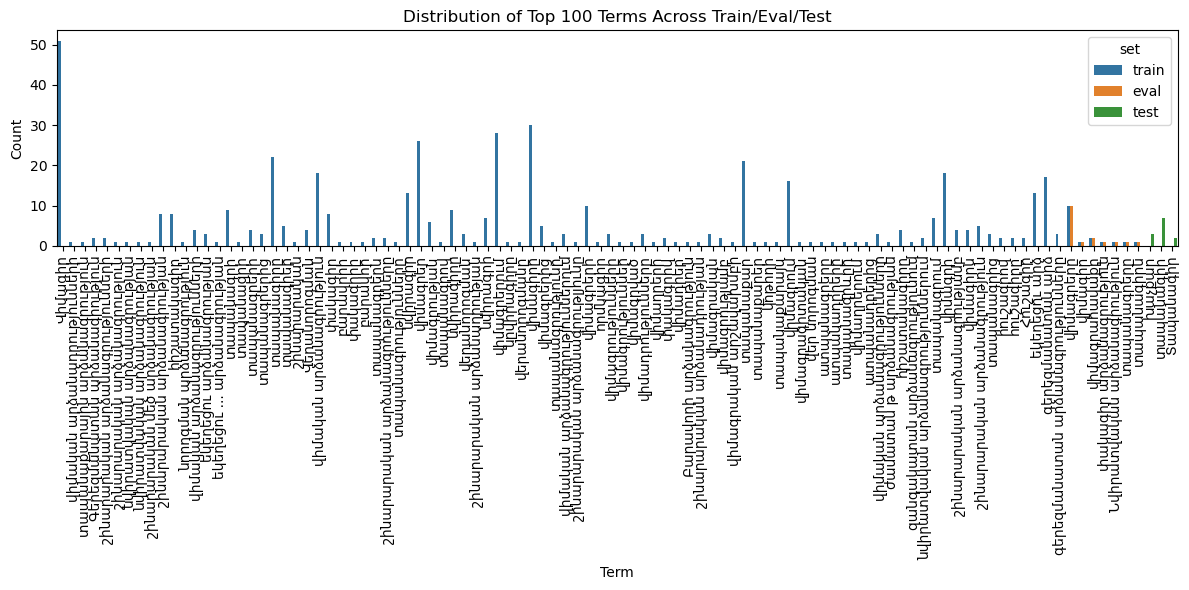

,term,set
0,Վիմագիր,train
1,վիմական արձանադրությունների,train
2,տապանաքարային արձանագրություն,train
3,Գերեզմանատան արձանագրություն,train
4,շինարարական արձանագրությունների,train
...,...,...
51758,NaN,test
51759,NaN,test
51760,NaN,test
51761,NaN,test


In [175]:
plot_term_distribution(train_df_doctored, eval_old, test_old, top_n=100)


## Retagging Old Data

In [186]:
eval_old= pd.read_csv('data/eval_ner_doctored.csv')
test_old= pd.read_csv('data/test_ner_doctored.csv')


In [187]:
test_old=test_old[['sentence','term']]
test_old['word']=test_old['sentence'].apply(lambda x: str(x).split())
test_old=test_old.explode('word')
test_old['tag'] = test_old.apply(lambda x: tag_logic(x['term'], x['word']), axis=1)
test_old['word_labels'] = test_old[['sentence','tag']].groupby('sentence').transform(lambda x: ','.join(x))
test_old.drop_duplicates(subset=['sentence'], inplace=True)
test_old

,sentence,term,word,tag,word_labels
0,վլանէս թրտաշվլանէս խաչքար է կանգնեցրել,խաչքար,վլանէս,O,"O,O,B-INSC,O,O"
1,սմբատ նահնշահ ովհաննես սմբատ հայոց թագավոր թթ ...,հարկ,սմբատ,O,"O,O,O,O,O,O,O,O,O,O,B-INSC,O,O"
2,սարգիս ձորավորաց եկեղեցու վանահայր խաչքարէ կան...,խաչքար,սարգիս,O,"O,O,O,O,B-INSC,O,O,O,O,O,O,O,O"
3,մարմաշեն հյ գերեզմանոց տապանագիր,տապանագիր,մարմաշեն,O,"O,O,O,B-INSC"
4,սարմաշեն գլխավոր տաճար հվ պատ արտ ոդ նվիրատվակ...,տապանագիր,սարմաշեն,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-INSC"
...,...,...,...,...,...
266,գրրածա ուրարտական պետության կացձում,NaN,գրրածա,O,"O,O,O,O"
267,թագավորական կամուրջ բանդիվան գյուղում թալին թա...,NaN,թագավորական,O,"O,O,O,O,O,O,O,O"
268,թաղք գյուղ արթիկի մերծակայքում որը նվիրաբերվել...,NaN,թաղք,O,"O,O,O,O,O,O,O,O"
269,իլխինապ իլխիաբ իլխիաբի գյուղ ալեքսանդրապոլի գա...,NaN,իլխինապ,O,"O,O,O,O,O,O,O,O"


In [188]:
eval_old=eval_old[['sentence','term']]
eval_old['word']=eval_old['sentence'].apply(lambda x: str(x).split())
eval_old=eval_old.explode('word')
eval_old['tag'] = eval_old.apply(lambda x: tag_logic(x['term'], x['word']), axis=1)
eval_old['word_labels'] = eval_old[['sentence','tag']].groupby('sentence').transform(lambda x: ','.join(x))
eval_old.drop_duplicates(subset=['sentence'], inplace=True)
eval_old

,sentence,term,word,tag,word_labels
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,գիմք,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN..."
1,արևելյան նիրակի ներկայիս հ շիրակի մարզ վիմագիր...,վիմագիր,արևելյան,O,"O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O,O..."
2,մեզ անհայտ պատճառով մարմաշենի վանքի և ձերծակայ...,վիմագրերը,մեզ,O,"O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O"
3,ծանոթ օրբելին ինչպես և մենք այս և հաջորդ վիմագ...,վիմագրերը,ծանոթ,O,"O,O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O"
4,այդ վիմագրերը վերջերս հրատարակվեցին մատենադարա...,վիմագրերը,այդ,O,"O,B-INSC,O,O,O,O,O,O,O,O,O"
...,...,...,...,...,...
264,յակոբ ապաչեան որմնադիր սառնաղբյուրի կամրջի,NaN,յակոբ,O,"O,O,O,O,O"
265,յակոբ արձանագրություն է կազմել,NaN,յակոբ,O,"O,O,O,O"
266,յակոբ դաւթեանց բանդիվան գյուղի հիմնադիրներից,NaN,յակոբ,O,"O,O,O,O,O"
267,յակոբ որդի ալէքսանի ննջեցյալ,NaN,յակոբ,O,"O,O,O,O"


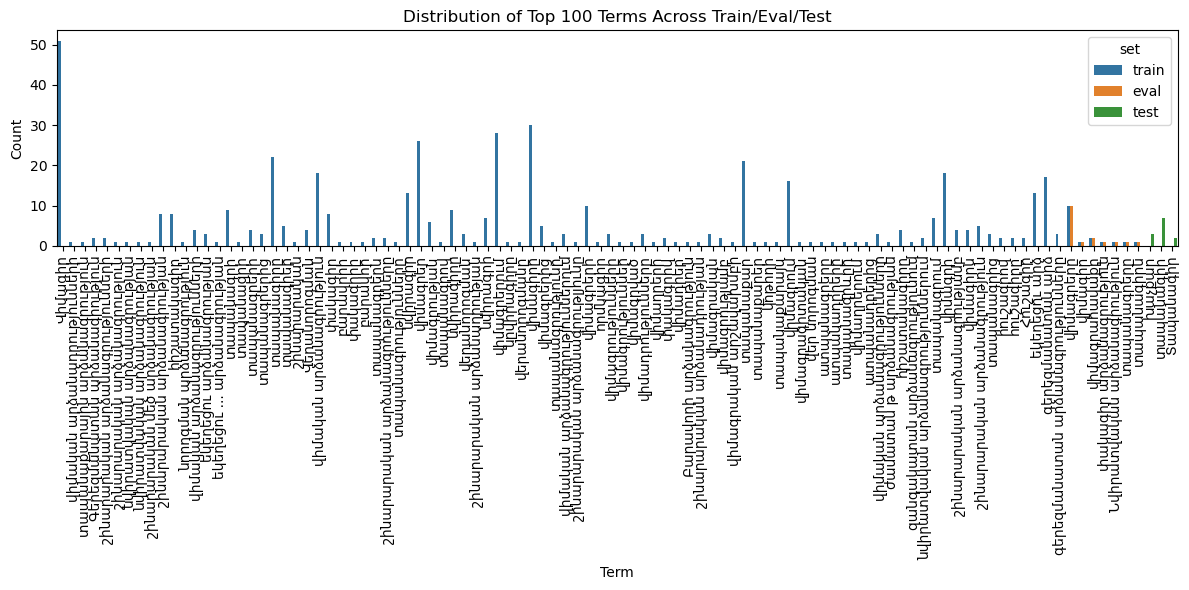

,term,set
0,Վիմագիր,train
1,վիմական արձանադրությունների,train
2,տապանաքարային արձանագրություն,train
3,Գերեզմանատան արձանագրություն,train
4,շինարարական արձանագրությունների,train
...,...,...
51758,NaN,test
51759,NaN,test
51760,NaN,test
51761,NaN,test


In [189]:
plot_term_distribution(train_df_doctored, eval_old, test_old, top_n=100)


In [190]:
eval_old.to_csv('data/eval_ner_doctored_v2.csv',index=False)
test_old.to_csv('data/test_ner_doctored_v2.csv',index=False)

## Saving Dataframes for Reproducibility

In [155]:
train_df.to_csv('data/train_ner.csv',index=False)
eval_df.to_csv('data/eval_ner.csv',index=False)
test_df.to_csv('data/test_ner.csv',index=False)

# Augmented Dataset

### Data Augmentation

In [156]:
AUGMENT = False

In [157]:
from pydantic import BaseModel,Field
from typing import Optional,List
import openai
import os
from openai import OpenAI

if AUGMENT:
    openai.api_key = os.environ['OPENAI_API_KEY']
    client = OpenAI()
    types_of_inscriptions = pd.read_csv('data/types_of_inscriptions.csv')
    print(types_of_inscriptions.head())
    terms_list = types_of_inscriptions.to_dict(orient="records")

class WordOfInterest(BaseModel):
    input: str = Field(None, description="Sentence containing word of interest")
    output: str= Field(None, description="word of interest : type of inscription")

class AugmentedData(BaseModel):
    sentences: List[WordOfInterest]

def augmenting_prompting(examples,terms):
    augmented_prompt = f"""You are an expert in the Armenian Language and Epigraphy. 
    Your task is to generate around at least 500 sentences in armenian containing the following terms of interest: {', '.join([term['Term'] for term in terms])}.
    The task at hand is to augment a dataset wih examples of sentences containing these words of interest.
    
    The original dataset is given below:
    {examples}

    There are around 3500 sentences that do not contain any of the words of interest.
    Your task is to balance the dataset by generating new sentences that include the words of interest.
    
    Please generate the sentences in the following JSON format:
    {{
        "terms": [
            {{
                "input": "Sentence containing word of interest",
                "output": "word of interest : type of inscription"
            }},
            ...
        ]
    }}
    
    Proceed in the following way:
    1. Look at the words of interests.
    2. Generate sentences containing these words, making sure to include the word of interest in each sentence.
    3. Ensure the sentences are diverse and contextually rich.
    4. Output field should **always** be in the format "word of interest : **type of inscription**".
    """
    return augmented_prompt

In [158]:
from pathlib import Path
from tqdm import tqdm

if AUGMENT:
    response = client.beta.chat.completions.parse(
            model="gpt-5",
                messages=[
                    {"role": "system", "content": "You are an assistant that extracts Armenian epigraphic terms."},
                    {"role": "user", "content": f"""
                    {augmenting_prompting(df_balance[~df_balance['output'].isna()].head().head().to_string(), terms_list)}
                    """}
                ],
                response_format=AugmentedData
            ).choices[0].message.parsed
    print(type(response)) 
    terms_only = {"sentences": [term.model_dump() for term in response.senteces]}  # convert Pydantic objects to dict
    
    out_file =  f"additionnal_examples.json"
    with open(out_file, "w", encoding="utf-8") as f:
        json.dump(terms_only, f, ensure_ascii=False, indent=2)
else:
    print('Augmentation already ran. If it needs to be ran again, change AUGMENT to True.')

Augmentation already ran. If it needs to be ran again, change AUGMENT to True.


In [217]:
import json  
if AUGMENT:
    with open('../preprocessing/additional_examples.json', "r", encoding="utf-8") as f:
        data = json.load(f)
    
    # Extract sentences
    sentences = data.get("sentences", [])  # adjust if it's actually "sentences"
    additional_examples = pd.DataFrame(sentences)

In [208]:
additional_examples.head()

,input,output
0,Արտաշատի հնավայրի նորաբաց քարետակ սալին պահպան...,Վիմագիր : type of inscription
1,Պատմաբանների խմբի այցելության ընթացքում մաքրվե...,Վիմագիր : type of inscription
2,Հին ճանապարհի եզրին կանգուն խաչքարի հիմքում բա...,Վիմագիր : type of inscription
3,Տեղական երաժշտական դպրոցի բակում գտնված բազալտ...,Վիմագիր : type of inscription
4,Հուշարձանի հյուսիսային պատի մոտ լուսանկարեցինք...,Վիմագիր : type of inscription


In [209]:
if AUGMENT:
    df = pd.read_json('data/divan10_final_data.jsonl', lines=True)
    augmented = pd.concat([df, additionnal_examples], ignore_index=True)
    augmented.head()

,input,output,term
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը: type of inscription,NaN
1,նախորդ հրատարակիչը վիմագրի ծանոթագրության մեջ ...,Վիմագիր: type of inscription,NaN
2,ոմն առյուծի հայր սխիթար ճոն հիշատակված է նաև ա...,վիմագրերից: type of inscription,NaN
3,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները: type of inscription,NaN
4,արևելյան նիրակի ներկայիս հ շիրակի մարզ վիմագիր...,վիմագիր: type of inscription,NaN


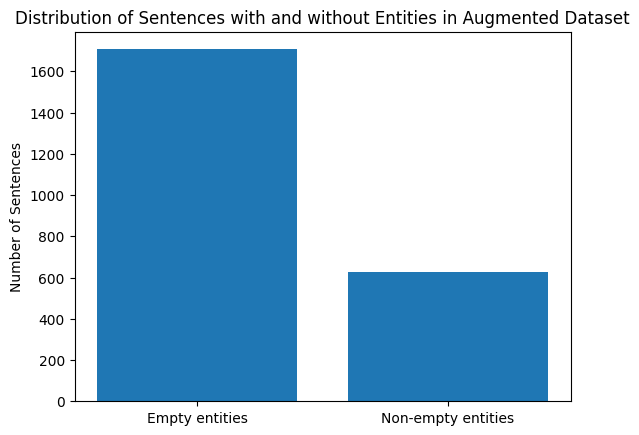

In [210]:
if AUGMENT:
    df_balance = augmented.copy()

    df_balance['output'] = df_balance['output'].replace('', pd.NA)
    
    empty_count = df_balance['output'].isna().sum()
    non_empty_count = (~df_balance['output'].isna()).sum()
    
    plt.bar(
        x=['Empty entities', 'Non-empty entities'],
        height=[empty_count, non_empty_count]
    )
    plt.ylabel('Number of Sentences')
    plt.title('Distribution of Sentences with and without Entities in Augmented Dataset')
    plt.show()

In [218]:
if AUGMENT:
    augmented['output'] = augmented['output'].apply(lambda x: x.split(':')[0] if ':' in str(x) else None)
    augmented.rename(columns={'input':'sentence','output':'term'}, inplace=True)
    augmented['word'] = augmented['sentence'].apply(lambda x: str(x).split())    
    augmented = augmented.explode('word')
    augmented['tag'] = augmented.apply(lambda x: tag_logic(x['term'], x['word']), axis=1)
    augmented['word_labels'] = augmented[['sentence', 'tag']].groupby('sentence').transform(lambda x: ','.join(x))
    augmented.drop_duplicates(subset=['sentence'], inplace=True)
    
    augmented.head()

In [219]:
if AUGMENT:
    train_df, eval_df, test_df = split_jsonl_dataset(augmented)
    dataset = plot_term_distribution(train_df, eval_df, test_df, top_n=100)

In [220]:
if AUGMENT:
    train_df.to_csv('data/train_ner_aug.csv',index=False)
    eval_df.to_csv('data/eval_ner_aug.csv',index=False)
    test_df.to_csv('data/test_ner_aug.csv',index=False)

### Augmenting the doctored Data

In [223]:
with open('../preprocessing/additional_examples.json', "r", encoding="utf-8") as f:
    data = json.load(f)

# Extract sentences
sentences = data.get("sentences", [])  # adjust if it's actually "sentences"
additional_examples = pd.DataFrame(sentences)

In [224]:
additional_examples['term'] = additional_examples['output'].apply(lambda x: x.split(':')[0].lower() if ':' in str(x) else None)
additional_examples['output'] = additional_examples['term'].apply(lambda x: str(x).lower() if x is not None else None)
peakless_examples = additional_examples[~additionnal_examples['term'].isin(testing_terms+[t.lower() for t in testing_terms])].reset_index(drop=True)
added_train,added_eval,_ = split_jsonl_dataset(peakless_examples,train_frac=0.75, eval_frac=0.25, test_frac=0, random_state=42)
added_train

,input,output,term
0,"Վերին հարթակում գտնվեց քարե սալ, որի վրա փորագ...",ջրօգտագործման արձանագրություն,ջրօգտագործման արձանագրություն
1,Գմբեթային անցքի տակ պահպանվում է Գմբեթային արձ...,գմբեթային արձանագրություն,գմբեթային արձանագրություն
2,Սրահի աջ անկյունում տեղադրված ցուցատախտակի տակ...,տապանաքարային վիմագիր,տապանաքարային վիմագիր
3,"Վանական կանոնակարգը ամփոփված է Կանոնագիր, որը ...",կանոնագիր,կանոնագիր
4,Ավանդույթների ուսումնասիրողը հրապարակեց հիշատա...,հիշատակագրային վիմագիր,հիշատակագրային վիմագիր
...,...,...,...
395,Գավթի սյան վրա փորագրված է Նվիրատվական արձանագ...,նվիրատվական արձանագրություն,նվիրատվական արձանագրություն
396,Դաշտային հեռադիտակով նկատվեց Դամբարանային արձա...,դամբարանային արձանագրություն,դամբարանային արձանագրություն
397,Սյունաշարի կենտրոնական սյան վրա պահպանվել է սյ...,սյունային արձանագրություն,սյունային արձանագրություն
398,"Գրախոսը նշել է, որ այս Օրհնագիր եզակի է իր վան...",օրհնագիր,օրհնագիր


In [225]:
added_train.drop(columns=['term'], inplace=True)
added_train.rename(columns={'input':'sentence','output':'term'}, inplace=True)
added_train['word'] = added_train['sentence'].apply(lambda x: str(x).split())    
print(added_train.columns)
added_train=  added_train.explode('word')
added_train['tag'] = added_train.apply(lambda x: tag_logic(x['term'], x['word']), axis=1)
added_train['word_labels'] = added_train[['sentence', 'tag']].groupby('sentence').transform(lambda x: ','.join(x))
added_train.drop_duplicates(subset=['sentence'], inplace=True)
added_train

Index(['sentence', 'term', 'word'], dtype='object')


,sentence,term,word,tag,word_labels
0,"Վերին հարթակում գտնվեց քարե սալ, որի վրա փորագ...",ջրօգտագործման արձանագրություն,Վերին,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O"
1,Գմբեթային անցքի տակ պահպանվում է Գմբեթային արձ...,գմբեթային արձանագրություն,Գմբեթային,O,"O,O,O,O,O,O,O,O,O"
2,Սրահի աջ անկյունում տեղադրված ցուցատախտակի տակ...,տապանաքարային վիմագիր,Սրահի,O,"O,O,O,O,O,O,O,O,B-INSC,O,O,O,O"
3,"Վանական կանոնակարգը ամփոփված է Կանոնագիր, որը ...",կանոնագիր,Վանական,O,"O,O,O,O,O,O,O,O,O,O,O,O"
4,Ավանդույթների ուսումնասիրողը հրապարակեց հիշատա...,հիշատակագրային վիմագիր,Ավանդույթների,O,"O,O,O,B-INSC,I-INSC,O,O,O,O,O,O"
...,...,...,...,...,...
395,Գավթի սյան վրա փորագրված է Նվիրատվական արձանագ...,նվիրատվական արձանագրություն,Գավթի,O,"O,O,O,O,O,O,O,O,O"
396,Դաշտային հեռադիտակով նկատվեց Դամբարանային արձա...,դամբարանային արձանագրություն,Դաշտային,O,"O,O,O,O,O,O,O,O,O,O"
397,Սյունաշարի կենտրոնական սյան վրա պահպանվել է սյ...,սյունային արձանագրություն,Սյունաշարի,O,"O,O,O,O,O,O,B-INSC,O,O,O"
398,"Գրախոսը նշել է, որ այս Օրհնագիր եզակի է իր վան...",օրհնագիր,Գրախոսը,O,"O,O,O,O,O,O,O,O,O,O,O"


In [226]:
added_train.term.unique()

array(['ջրօգտագործման արձանագրություն ', 'գմբեթային արձանագրություն ',
       'տապանաքարային վիմագիր ', 'կանոնագիր ', 'հիշատակագրային վիմագիր ',
       'նվիրագիր ', 'վերանորոգման, նորոգման արձանագրություն ',
       'գավիթային արձանագրություն ', 'կոթողային արձանագրություն ',
       'վիմագիր ', 'թագավորական արձանագրություն ',
       'եկեղեցու արձանագրություն ', 'նվիրատվական արձանագրություն ',
       'ապարանքների շինարարական արձանագրություններ ',
       'կառուցողական արձանագրություն ', 'սյունային արձանագրություն ',
       'իշխանական արձանագրություն ', 'դռնագիր ',
       'վանական արձանագրություն ', 'տապանագիր ',
       'մատենագիտական արձանագրություն ', 'դամբարանախուցի մակագրություն ',
       'կանոնաիրավական արձանագրություն ', 'դամբարանային արձանագրություն ',
       'հարկային արձանագրություն ', 'օրհնագիր ',
       'փակագիր արձանագրություն ', 'շրջագիր ծածկագիր ',
       'տապանաքարային արձանագրություն ', 'պետրոգլիֆ ', 'ժայռապատկեր ',
       'վերակառուցման արձանագրություն ', 'ժամատան արձանագրո

```'water use protocol ', 'dome protocol ',
'tombstone epitaph ', 'statute ', 'memorial epitaph ',
'donation epitaph ', 'renovation, renovation protocol ',
'porch protocol ', 'monumental protocol ',
'epitaph ', 'royal protocol ',
'church protocol ', 'donation protocol ',
'building protocols of palaces ',
'constructive protocol ', 'columnar protocol'
```

In [227]:
added_eval.drop(columns=['term'], inplace=True)
added_eval.rename(columns={'input':'sentence','output':'term'}, inplace=True)
added_eval['word']=added_eval['sentence'].apply(lambda x: str(x).split())    
added_eval = added_eval.explode('word')
added_eval['tag'] = added_eval.apply(lambda x: tag_logic(x['term'], x['word']),axis=1)
added_eval['word_labels'] = added_eval[['sentence','tag']].groupby('sentence').transform(lambda x: ','.join(x))
added_eval.drop_duplicates(subset=['sentence'], inplace=True)
added_eval

,sentence,term,word,tag,word_labels
0,Արխիվային տեղեկագրում լուսաբանվեց անհայտ Հուշա...,հուշագիր,Արխիվային,O,"O,O,O,O,O,O,O,O,O"
1,Լեռան լանջին տեղադրված խաչքարի հիմքում կա Հուշ...,հուշագիր,Լեռան,O,"O,O,O,O,O,O,O,O,O,O,O"
2,Տեղում պահպանված վիմական արձանագրություն ցույց...,վիմական արձանագրություն,Տեղում,O,"O,O,B-INSC,I-INSC,O,O,O,O,O,O,O"
3,Հնագետներն արձանագրեցին հիշատակագիր՝ որում նշվ...,հիշատակագիր,Հնագետներն,O,"O,O,O,O,O,O,O,O,O"
4,Արձանագրության գրականության մեջ հաճախ է հիշատա...,խաչքարային արձանագրություն,Արձանագրության,O,"O,O,O,O,O,O,O,O,O,O,O,O"
...,...,...,...,...,...
115,Տեղական համայնքն իր միջոցներով մաքրեց Տաղավարի...,տաղավարի արձանագրություն,Տեղական,O,"O,O,O,O,O,O,O,O,O,O"
116,Դաշտային նոթերում ընդգրկվեց այս գերեզմանատան ա...,գերեզմանատան արձանագրություն,Դաշտային,O,"O,O,O,O,B-INSC,O,O,O,O,O"
117,"Քանդակագործական արհեստանոցում ցույց տրվեց, թե ...",սյունագիր,Քանդակագործական,O,"O,O,O,O,O,O,O,O,O,O,O,O"
118,Մատենադարանի ցուցասրահում ներկայացված հիշատակա...,հիշատակագիր,Մատենադարանի,O,"O,O,O,B-INSC,O,O,O,O,O"


In [228]:
train_aug_doc = pd.concat([train_df_doctored, added_train], ignore_index=True)
eval_aug_doc = pd.concat([eval_df_doctored, added_eval], ignore_index=True)

train_aug_doc.to_csv('data/train_ner_aug_doctored.csv',index=False)
eval_aug_doc.to_csv('data/eval_ner_aug_doctored.csv',index=False)

train_aug_doc

,sentence,term,word,tag,word_labels
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,գիմք,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN..."
1,նախորդ հրատարակիչը վիմագրի ծանոթագրության մեջ ...,Վիմագիր,նախորդ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
2,ոմն առյուծի հայր սխիթար ճոն հիշատակված է նաև ա...,վիմագրերից,ոմն,O,"O,O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O..."
3,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները,պրակն,O,"O,O,O,O,O,B-INSC,I-INSC"
4,արևելյան նիրակի ներկայիս հ շիրակի մարզ վիմագիր...,վիմագիր,արևելյան,O,"O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O,O..."
...,...,...,...,...,...
1602,Գավթի սյան վրա փորագրված է Նվիրատվական արձանագ...,նվիրատվական արձանագրություն,Գավթի,O,"O,O,O,O,O,O,O,O,O"
1603,Դաշտային հեռադիտակով նկատվեց Դամբարանային արձա...,դամբարանային արձանագրություն,Դաշտային,O,"O,O,O,O,O,O,O,O,O,O"
1604,Սյունաշարի կենտրոնական սյան վրա պահպանվել է սյ...,սյունային արձանագրություն,Սյունաշարի,O,"O,O,O,O,O,O,B-INSC,O,O,O"
1605,"Գրախոսը նշել է, որ այս Օրհնագիր եզակի է իր վան...",օրհնագիր,Գրախոսը,O,"O,O,O,O,O,O,O,O,O,O,O"


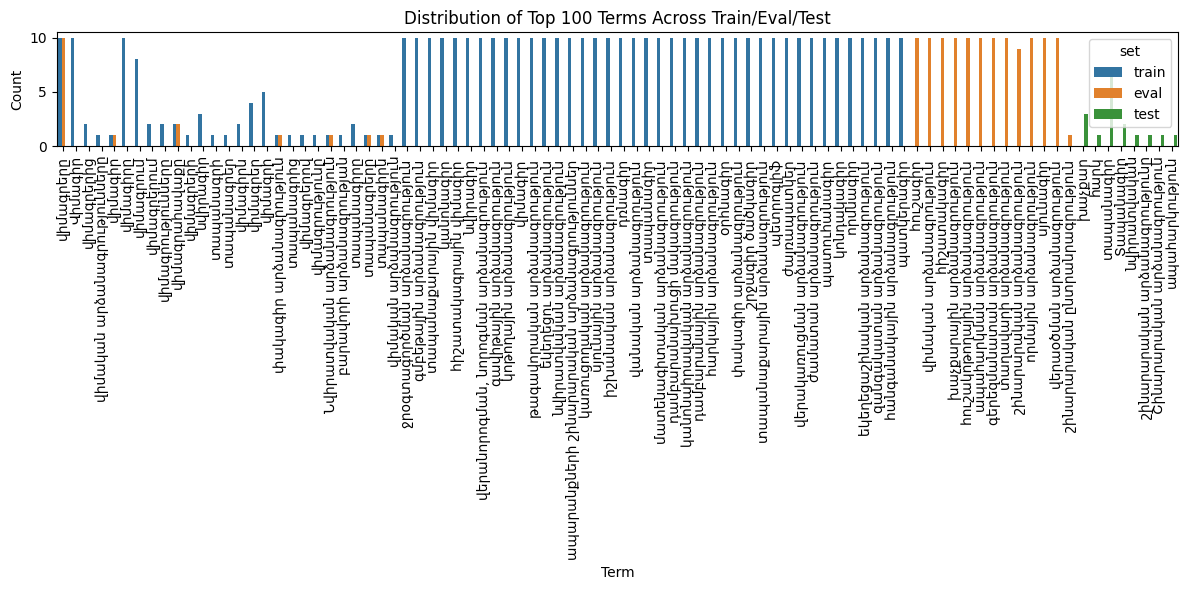

In [229]:
dfp = plot_term_distribution(train_aug_doc, eval_aug_doc, test_df_doctored, top_n=100)

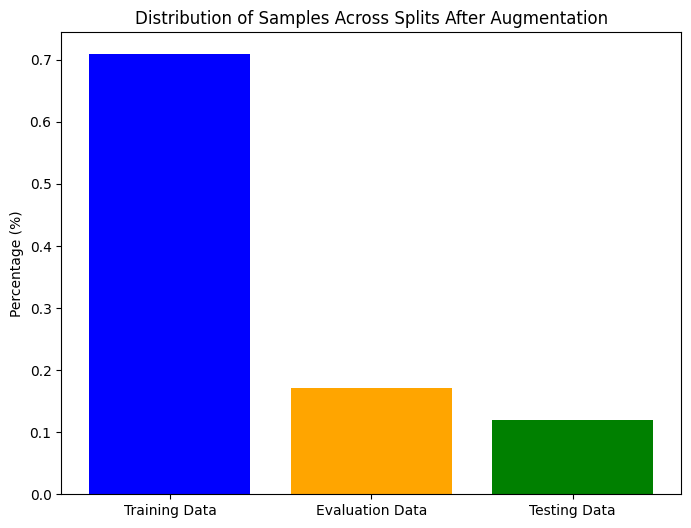

In [230]:
total_aug_len = len(train_aug_doc) + len(eval_aug_doc) + len(test_df_doctored)
relative_aug_len = [len(train_aug_doc)/total_aug_len, len(eval_aug_doc)/total_aug_len, len(test_df_doctored)/total_aug_len]
labels = ['Training Data', 'Evaluation Data', 'Testing Data']
plt.figure(figsize=(8,6))
plt.bar(labels, relative_aug_len, color=['blue', 'orange', 'green'])
plt.ylabel('Percentage (%)')
plt.title('Distribution of Samples Across Splits After Augmentation')
plt.show()


In [231]:
test_df_doctored.term.unique()

array(['խաչքար', 'հարկ', 'տապանագիր', 'Տապանագիր', 'նվիրատվական',
       'շինարարական արձանագրությունը', 'Շինարարական արձանագրություն',
       'ապահարկություն', None], dtype=object)